# Notebook 1: Filtrations of Simplicial Complexes

## Exploring Topological Structures in Data with GUDHI

In this notebook, you will explore how **filtrations of simplicial complexes** can reveal the hidden shape (topology) of a point cloud. You will learn:

1. **Simplicial Complexes** — What they are and how to build them from data
2. **Filtrations** — How a single complex becomes a family parameterized by a scale
3. **Vietoris–Rips Complex** — The most common construction based on pairwise distances
4. **Čech Complex** — A topologically correct but computationally expensive alternative
5. **Alpha Complex** — An efficient construction based on the Delaunay triangulation
6. **Comparing the Three** — Side-by-side visualization and discussion of trade-offs

---

**Prerequisites:** Lectures 15 and 16 (simplicial complexes, filtrations, persistent homology).

**Author:** Alejandro Ucan-Puc  
**Last Updated:** February 2026

In [22]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scipy gudhi tadasets

  Using cached tadasets-0.2.2-py3-none-any.whl.metadata (3.9 kB)
Using cached tadasets-0.2.2-py3-none-any.whl (9.7 kB)


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.tri as mtri
from matplotlib.collections import PatchCollection
from matplotlib import cm
from scipy.spatial import Delaunay
from scipy.spatial.distance import squareform, pdist
import gudhi
import tadasets

---

## 1. Simplicial Complexes

### What is a Simplex?

A **$k$-simplex** is the convex hull of $k+1$ affinely independent points:

- **0-simplex**: a single vertex $\{v_0\}$
- **1-simplex**: an edge $\{v_0, v_1\}$
- **2-simplex**: a (filled) triangle $\{v_0, v_1, v_2\}$
- **3-simplex**: a (solid) tetrahedron $\{v_0, v_1, v_2, v_3\}$

A **face** of a simplex $\sigma$ is any subset of its vertices. The closed simplex $\bar{\sigma}$ contains $\sigma$ and all its faces.

### What is a Simplicial Complex?

A **simplicial complex** $K$ is a finite collection of simplices such that:
1. If $\sigma \in K$ and $\tau$ is a face of $\sigma$, then $\tau \in K$ (**closure property**)
2. The intersection of any two simplices in $K$ is either empty or a face of both (**intersection property**)

The **dimension** of $K$ is the maximum dimension of its simplices.

### From Point Clouds

Given a point cloud $P = \{p_1, \ldots, p_n\} \subset \mathbb{R}^d$ and a scale $r \geq 0$, we can build simplicial complexes that encode the proximity structure of the data. The three most common constructions are the **Vietoris–Rips**, **Čech**, and **Alpha** complexes — studied in Sections 3–5.

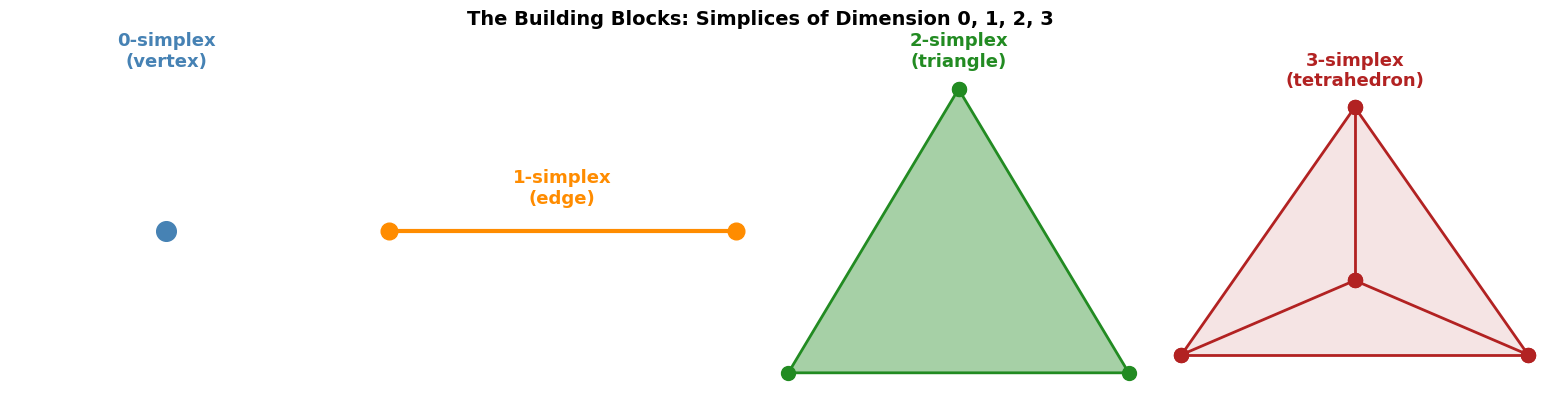

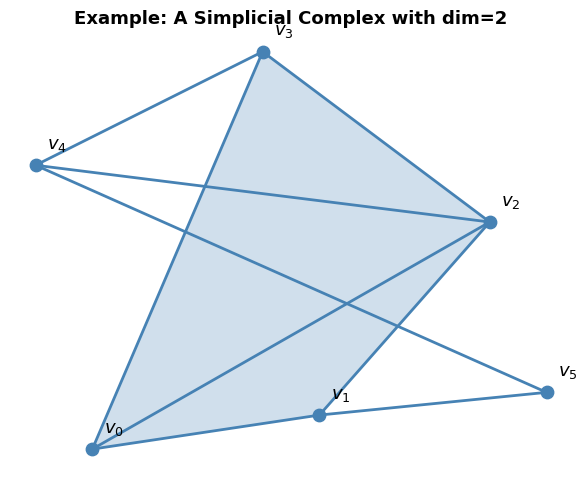

This complex has:
  6 vertices (0-simplices)
  9 edges    (1-simplices)
  2 triangles (2-simplices)
  Euler characteristic χ = V - E + F = 6 - 9 + 2 = -1


In [24]:
import itertools

def plot_simplex_example():
    """Visualize simplices of dimension 0, 1, 2, and 3."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    titles = ['0-simplex\n(vertex)', '1-simplex\n(edge)', '2-simplex\n(triangle)', '3-simplex\n(tetrahedron)']
    colors = ['steelblue', 'darkorange', 'forestgreen', 'firebrick']

    # 0-simplex: single vertex
    axes[0].scatter([0], [0], s=200, c=colors[0], zorder=5)
    axes[0].set_xlim(-1, 1); axes[0].set_ylim(-1, 1)

    # 1-simplex: two vertices and an edge
    verts_1 = np.array([[-0.5, 0], [0.5, 0]])
    axes[1].plot(verts_1[:, 0], verts_1[:, 1], '-o', color=colors[1], ms=12, lw=3)

    # 2-simplex: triangle (filled)
    verts_2 = np.array([[0, 0.6], [-0.6, -0.4], [0.6, -0.4]])
    tri = plt.Polygon(verts_2, color=colors[2], alpha=0.4)
    axes[2].add_patch(tri)
    axes[2].plot(*np.vstack([verts_2, verts_2[0]]).T, '-o', color=colors[2], ms=10, lw=2)

    # 3-simplex: tetrahedron projected to 2D
    verts_3 = np.array([[0, 0.7], [-0.7, -0.3], [0.7, -0.3], [0, 0]])  # rough projection
    for i, j in itertools.combinations(range(4), 2):
        axes[3].plot([verts_3[i, 0], verts_3[j, 0]],
                     [verts_3[i, 1], verts_3[j, 1]], '-o', color=colors[3], ms=10, lw=2)
    # shade visible faces
    for face in [[0, 1, 3], [0, 2, 3], [1, 2, 3]]:
        axes[3].fill(verts_3[face, 0], verts_3[face, 1], color=colors[3], alpha=0.12)

    for ax, title, color in zip(axes, titles, colors):
        ax.set_title(title, fontsize=13, fontweight='bold', color=color)
        ax.set_aspect('equal')
        ax.axis('off')

    plt.suptitle('The Building Blocks: Simplices of Dimension 0, 1, 2, 3',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_simplex_example()

# ── Now show a small simplicial complex built from these pieces ─────────────────
fig, ax = plt.subplots(figsize=(6, 6))

verts = np.array([[0, 0], [2, 0.3], [3.5, 2], [1.5, 3.5], [-0.5, 2.5], [4, 0.5]])
# Faces (2-simplices)
faces = [[0, 1, 2], [0, 2, 3]]
for f in faces:
    tri = verts[f]
    ax.fill(tri[:, 0], tri[:, 1], 'steelblue', alpha=0.25)
# Edges (1-simplices)
edges = [[0,1],[1,2],[2,3],[0,3],[0,2],[3,4],[2,4],[4,5],[1,5]]
for e in edges:
    ax.plot(verts[e, 0], verts[e, 1], 'steelblue', linewidth=2)
# Vertices (0-simplices)
ax.scatter(verts[:, 0], verts[:, 1], s=80, c='steelblue', zorder=5)
for i, (x, y) in enumerate(verts):
    ax.annotate(f'$v_{i}$', (x + 0.1, y + 0.15), fontsize=13)

ax.set_title('Example: A Simplicial Complex with dim=2', fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

print("This complex has:")
print(f"  {len(verts)} vertices (0-simplices)")
print(f"  {len(edges)} edges    (1-simplices)")
print(f"  {len(faces)} triangles (2-simplices)")
print(f"  Euler characteristic χ = V - E + F = {len(verts)} - {len(edges)} + {len(faces)} = {len(verts)-len(edges)+len(faces)}")

---

## 2. Filtrations

### What is a Filtration?

Given a simplicial complex $K$, a **filtration** is a nested family of subcomplexes parameterized by a real number $r$:

$$\emptyset = K_{r_0} \subseteq K_{r_1} \subseteq K_{r_2} \subseteq \cdots \subseteq K_{r_m} = K$$

As $r$ increases, newly born simplices are added but none are ever removed. Each simplex $\sigma$ is assigned a **birth value** $f(\sigma) = \min\{r : \sigma \in K_r\}$.

### Why Filtrations?

A single simplicial complex at a fixed scale $r$ can be misleading:
- Too small: the complex is disconnected (misses real structure)
- Too large: the complex is one big contractible blob (misses holes)

A filtration **tracks topology across all scales simultaneously**, enabling *persistent homology* (the subject of Notebook 2).

### The Gudhi `SimplexTree`

In `gudhi`, a filtration is stored in a `SimplexTree` object. Each simplex is stored together with its birth value. Key methods:

| Method | Description |
|---|---|
| `create_simplex_tree(max_dimension=k)` | Build the simplex tree up to dimension $k$ |
| `get_filtration()` | Iterate over `(simplex, filtration_value)` pairs in order |
| `num_simplices()` | Total number of simplices |
| `num_vertices()` | Number of 0-simplices (points) |
| `dimension()` | Maximum dimension |
| `prune_above_filtration(r)` | Keep only simplices with birth ≤ r |

Total simplices: 63
Unique filtration values: 22
First 10 birth values: [0.0, 5.0, 5.385, 5.831, 6.083, 6.325, 6.708, 7.28, 8.944, 9.434]



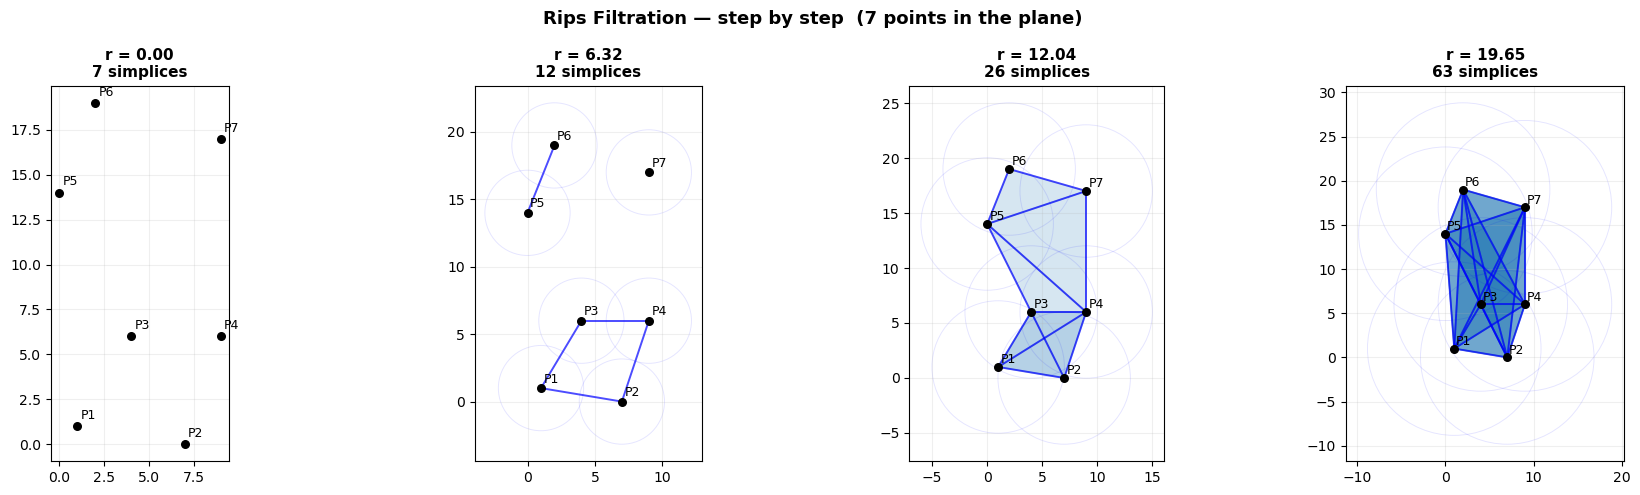

The filtration captures the connectivity of the data at each scale.
At r = diameter, the complex is fully connected (contractible to a point).


In [25]:
# ── Section 2, Part 2: Step-by-step filtration on a small point cloud ──────────
# 7 points, same as original notebook
pts_filt = np.array([[1, 1], [7, 0], [4, 6], [9, 6], [0, 14], [2, 19], [9, 17]], dtype=float)
labels = [f'P{i+1}' for i in range(len(pts_filt))]

# Build the full filtration up to the diameter
diam = pdist(pts_filt).max()
rips = gudhi.RipsComplex(points=pts_filt, max_edge_length=diam)
st = rips.create_simplex_tree(max_dimension=2)

# Collect all unique filtration values (birth times of simplices)
filt_values = sorted(set(v for _, v in st.get_filtration()))
print(f"Total simplices: {st.num_simplices()}")
print(f"Unique filtration values: {len(filt_values)}")
print(f"First 10 birth values: {[round(v, 3) for v in filt_values[:10]]}\n")

# Visualise the complex at 4 specific scale snapshots
snapshots = [filt_values[0], filt_values[5], filt_values[12], diam]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, r in zip(axes, snapshots):
    snap_st = gudhi.RipsComplex(points=pts_filt, max_edge_length=r).create_simplex_tree(max_dimension=2)

    for simplex, _ in snap_st.get_filtration():
        if len(simplex) == 3:
            tri = pts_filt[simplex]
            ax.fill(tri[:, 0], tri[:, 1], color='tab:blue', alpha=0.18)
        elif len(simplex) == 2:
            e = pts_filt[simplex]
            ax.plot(e[:, 0], e[:, 1], 'b-', linewidth=1.4, alpha=0.7)

    for pt in pts_filt:
        ax.add_patch(mpatches.Circle(pt, radius=r / 2, fc='none', ec='b', alpha=0.10, linewidth=0.7))

    ax.scatter(pts_filt[:, 0], pts_filt[:, 1], s=30, c='k', zorder=6)
    for lbl, (x, y) in zip(labels, pts_filt):
        ax.annotate(lbl, (x + 0.2, y + 0.4), fontsize=9)

    n_simp = snap_st.num_simplices()
    ax.set_title(f'r = {r:.2f}\n{n_simp} simplices', fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle('Rips Filtration — step by step  (7 points in the plane)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("The filtration captures the connectivity of the data at each scale.")
print("At r = diameter, the complex is fully connected (contractible to a point).")

---

## 3. Three Types of Simplicial Complexes

Given a finite point cloud $P \subset \mathbb{R}^d$ and a scale parameter $r \geq 0$, there are three standard constructions.

### 3.1 Vietoris–Rips Complex

**Definition.** The Vietoris–Rips complex $\mathcal{R}(r)$ of $P$ contains a simplex $\sigma = \{p_0, p_1, \ldots, p_k\}$ if and only if **every pair** of points in $\sigma$ is within distance $r$:

$$\sigma \in \mathcal{R}(r) \iff d(p_i, p_j) \leq r \text{ for all } i, j$$

**Flag complex.** Rips is a *flag* complex: it is fully determined by its 1-skeleton (edges). If every two vertices of a potential higher simplex are connected by an edge, the simplex is included.

**In GUDHI:** `gudhi.RipsComplex` accepts either a point cloud (`points=`) or a precomputed distance matrix (`distance_matrix=`) and a `max_edge_length` threshold.

**When to use it:**
- ✅ Data given as a distance matrix (not necessarily Euclidean)
- ✅ High-dimensional data
- ❌ Large datasets in low dimension (Alpha is more efficient)

Euclidean distance matrix:
       P1     P2     P3     P4     P5     P6     P7
P1   0.00   6.08   5.83   9.43  13.04  18.03  17.89
P2   6.08   0.00   6.71   6.32  15.65  19.65  17.12
P3   5.83   6.71   0.00   5.00   8.94  13.15  12.08
P4   9.43   6.32   5.00   0.00  12.04  14.76  11.00
P5  13.04  15.65   8.94  12.04   0.00   5.39   9.49
P6  18.03  19.65  13.15  14.76   5.39   0.00   7.28
P7  17.89  17.12  12.08  11.00   9.49   7.28   0.00

Diameter of the point cloud: 19.6469
We will use max_edge_length = 20

Vietoris–Rips — full filtration:
  Dimension : 2
  Simplices : 63
  Vertices  : 7

[0]  ->  r = 0.0000
[1]  ->  r = 0.0000
[2]  ->  r = 0.0000
[3]  ->  r = 0.0000
[4]  ->  r = 0.0000
[5]  ->  r = 0.0000
[6]  ->  r = 0.0000
[2, 3]  ->  r = 5.0000
[4, 5]  ->  r = 5.3852
[0, 2]  ->  r = 5.8310
[0, 1]  ->  r = 6.0828
[1, 3]  ->  r = 6.3246
[1, 2]  ->  r = 6.7082
[0, 1, 2]  ->  r = 6.7082
[1, 2, 3]  ->  r = 6.7082
[5, 6]  ->  r = 7.2801
[2, 4]  ->  r = 8.9443
[0, 3]  ->  r = 9.4340
[0,

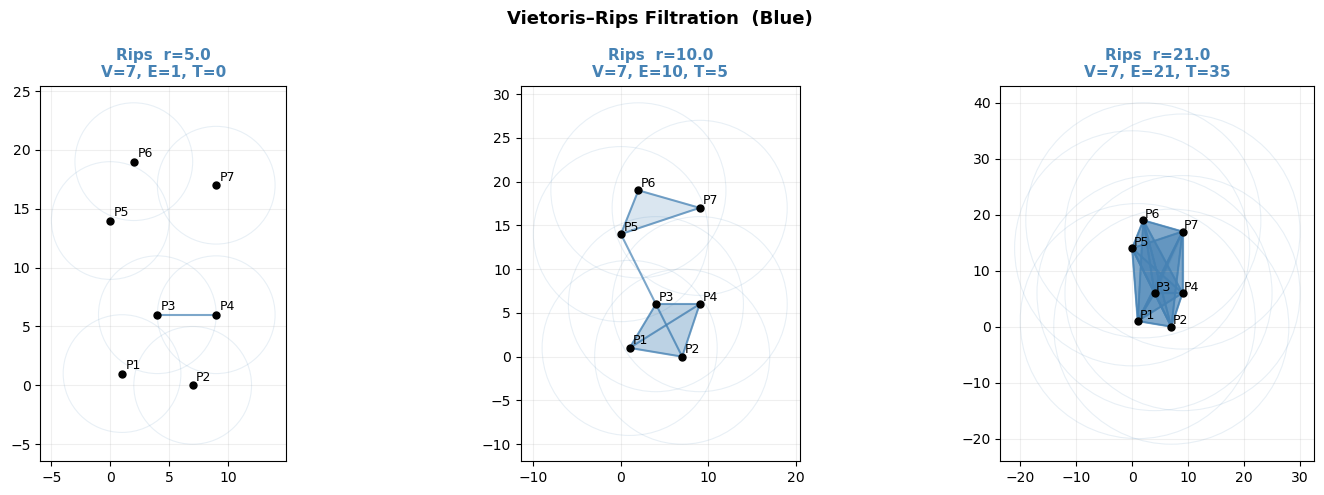


Observation: as r grows, more edges and triangles are added.
At r=21 (≥ diameter) all simplices are present: the complex is the full 6-simplex.


In [26]:
# ── Section 3.1: Vietoris–Rips Complex with GUDHI ─────────────────────────────
pts = np.array([[1, 1], [7, 0], [4, 6], [9, 6], [0, 14], [2, 19], [9, 17]], dtype=float)
point_labels = [f'P{i+1}' for i in range(len(pts))]

# Euclidean distance matrix
dist_df = pd.DataFrame(
    squareform(pdist(pts, 'euclidean')),
    index=point_labels, columns=point_labels
)
print("Euclidean distance matrix:")
print(dist_df.round(2))
diam = dist_df.values.max()
print(f"\nDiameter of the point cloud: {diam:.4f}")
print(f"We will use max_edge_length = {np.ceil(diam):.0f}\n")

# Build the Rips complex
rips_complex = gudhi.RipsComplex(points=pts, max_edge_length=float(np.ceil(diam)))
simplex_tree_rips = rips_complex.create_simplex_tree(max_dimension=2)

print("Vietoris–Rips — full filtration:")
print(f"  Dimension : {simplex_tree_rips.dimension()}")
print(f"  Simplices : {simplex_tree_rips.num_simplices()}")
print(f"  Vertices  : {simplex_tree_rips.num_vertices()}\n")

fmt = '%s  ->  r = %.4f'
for simplex, filt_val in simplex_tree_rips.get_filtration():
    print(fmt % (simplex, filt_val))

# ── Visualize three snapshots of the filtration ────────────────────────────────
r_vals = [5.0, 10.0, 21.0]   # increasing scale

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, r in zip(axes, r_vals):
    st_snap = gudhi.RipsComplex(points=pts, max_edge_length=r).create_simplex_tree(max_dimension=2)

    # Draw 2-simplices first (so edges/vertices are drawn on top)
    for simplex, _ in st_snap.get_filtration():
        if len(simplex) == 3:
            tri = pts[simplex, :]
            ax.fill(tri[:, 0], tri[:, 1], color='steelblue', alpha=0.20)

    # Draw 1-simplices
    for simplex, _ in st_snap.get_filtration():
        if len(simplex) == 2:
            e = pts[simplex, :]
            ax.plot(e[:, 0], e[:, 1], color='steelblue', linewidth=1.5, alpha=0.7)

    # Draw balls of radius r
    for pt in pts:
        c = mpatches.Circle(pt, radius=r, fc='none', ec='steelblue', alpha=0.12, linewidth=0.8)
        ax.add_patch(c)

    ax.scatter(pts[:, 0], pts[:, 1], s=25, c='k', zorder=5)
    for lbl, (x, y) in zip(point_labels, pts):
        ax.annotate(lbl, (x + 0.3, y + 0.4), fontsize=9)

    n0 = sum(1 for s, _ in st_snap.get_filtration() if len(s) == 1)
    n1 = sum(1 for s, _ in st_snap.get_filtration() if len(s) == 2)
    n2 = sum(1 for s, _ in st_snap.get_filtration() if len(s) == 3)
    ax.set_title(f'Rips  r={r}\nV={n0}, E={n1}, T={n2}', fontsize=11, fontweight='bold', color='steelblue')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle('Vietoris–Rips Filtration  (Blue)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservation: as r grows, more edges and triangles are added.")
print("At r=21 (≥ diameter) all simplices are present: the complex is the full 6-simplex.")

### 3.2 Čech Complex

**Definition.** The Čech complex $\mathcal{C}(r)$ of a point cloud $P$ at scale $r$ contains a simplex $\sigma = \{p_0, p_1, \ldots, p_k\}$ if and only if the **closed balls** $\overline{B}(p_i, r/2)$ centred at its vertices have a **non-empty common intersection**:

$$\sigma \in \mathcal{C}(r) \iff \bigcap_{p_i \in \sigma} \overline{B}(p_i, \tfrac{r}{2}) \neq \emptyset$$

**Nerve Theorem.** The Čech complex is homotopy equivalent to the union of balls $\bigcup_{p \in P} B(p, r/2)$. This makes it geometrically faithful.

**Interleaving with Rips:**
$$\mathcal{C}(r) \subseteq \mathcal{R}(r) \subseteq \mathcal{C}(\sqrt{2}\, r)$$

**In GUDHI:** `gudhi.CechComplex` accepts either a point cloud or a distance matrix together with `max_radius`.

**When to use it:**
- ✅ Theoretical analysis (it has the correct homotopy type)
- ✅ Small datasets where correctness matters more than speed
- ❌ Large datasets (checking common-point intersections is expensive)

Čech Complex — filtration (radius parameter):
  Dimension : 2
  Simplices : 63  (V=7, E=21, T=35)
  Vertices  : 7

[0]  ->  r = 0.0000
[1]  ->  r = 0.0000
[2]  ->  r = 0.0000
[3]  ->  r = 0.0000
[4]  ->  r = 0.0000
[5]  ->  r = 0.0000
[6]  ->  r = 0.0000
[2, 3]  ->  r = 2.5000
[4, 5]  ->  r = 2.6926
[0, 2]  ->  r = 2.9155
[0, 1]  ->  r = 3.0414
[1, 3]  ->  r = 3.1623
[1, 2]  ->  r = 3.3541
[1, 2, 3]  ->  r = 3.5355
[0, 1, 2]  ->  r = 3.6050
[5, 6]  ->  r = 3.6401
[2, 4]  ->  r = 4.4721
[0, 3]  ->  r = 4.7170
[0, 1, 3]  ->  r = 4.7170
[0, 2, 3]  ->  r = 4.7170
[4, 6]  ->  r = 4.7434
[4, 5, 6]  ->  r = 4.7434
[3, 6]  ->  r = 5.5000
[3, 4]  ->  r = 6.0208
[2, 3, 4]  ->  r = 6.0208
[2, 6]  ->  r = 6.0415
[2, 3, 6]  ->  r = 6.0415
[2, 4, 6]  ->  r = 6.1029
[3, 4, 6]  ->  r = 6.3465
[0, 4]  ->  r = 6.5192
[0, 2, 4]  ->  r = 6.5192
[2, 5]  ->  r = 6.5765
[2, 4, 5]  ->  r = 6.5765
[2, 5, 6]  ->  r = 6.6495
[0, 3, 4]  ->  r = 6.7943
[3, 5]  ->  r = 7.3824
[2, 3, 5]  ->  r = 7.3824
[3, 4, 5]  ->

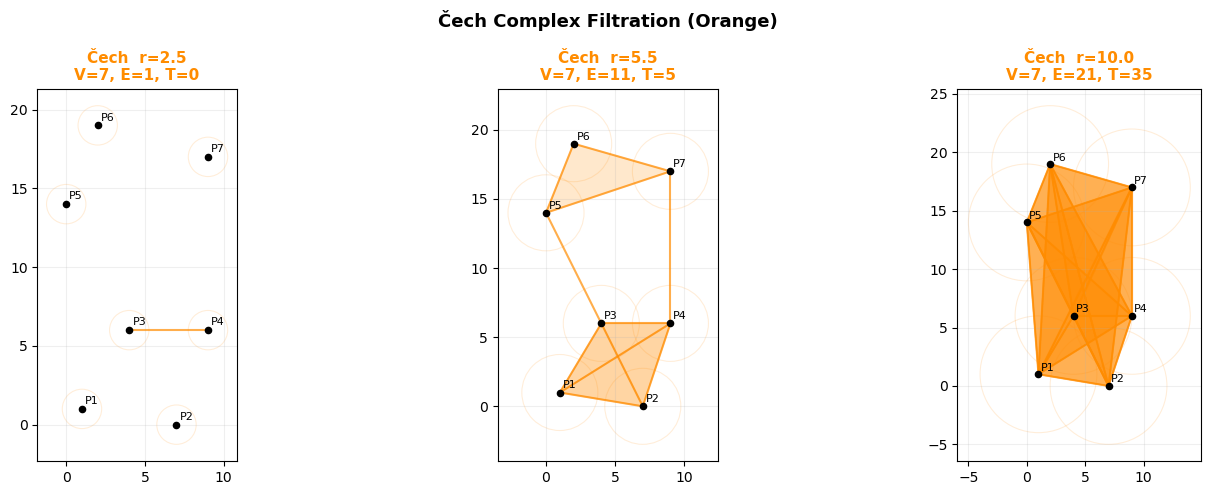


Note: Čech adds a simplex only when the balls of radius r centred at its vertices
share a COMMON point — geometrically more conservative than Rips.


In [27]:
# ── Section 3.2: Čech Complex — manual construction (no gudhi.CechComplex needed) ──
#
# gudhi.CechComplex requires CGAL bindings that may not be compiled in all
# distributions. We reconstruct it directly from the definition:
#   σ ∈ C(r)  ⟺  the minimum enclosing ball of the vertices of σ has radius ≤ r
#
# For simplices up to dimension 2 the MEB radius has a closed form:
#   dim 0 : 0
#   dim 1 : d(p,q)/2
#   dim 2 : circumradius if acute triangle, else half the longest edge (obtuse/right)

import itertools

def meb_radius(pts):
    """Minimum enclosing ball radius for up to 3 points in R^d."""
    pts = np.asarray(pts, dtype=float)
    n = len(pts)
    if n == 1:
        return 0.0
    if n == 2:
        return np.linalg.norm(pts[1] - pts[0]) / 2.0
    # n == 3
    p0, p1, p2 = pts
    d01 = np.linalg.norm(p1 - p0)
    d12 = np.linalg.norm(p2 - p1)
    d02 = np.linalg.norm(p2 - p0)
    # Check which angle (if any) is ≥ 90° — obtuse at vertex opposite to longest edge
    if d12 ** 2 >= d01 ** 2 + d02 ** 2:   # obtuse at p0
        return d12 / 2.0
    if d02 ** 2 >= d01 ** 2 + d12 ** 2:   # obtuse at p1
        return d02 / 2.0
    if d01 ** 2 >= d02 ** 2 + d12 ** 2:   # obtuse at p2
        return d01 / 2.0
    # Acute triangle → circumradius = abc / (4 * area)
    area = abs(np.cross(p1 - p0, p2 - p0)) / 2.0
    if area < 1e-12:                       # degenerate (collinear)
        return max(d01, d12, d02) / 2.0
    return (d01 * d12 * d02) / (4.0 * area)


def build_cech_filtration(points, max_radius, max_dim=2):
    """Return a list of (simplex, filtration_value) pairs sorted by value."""
    n = len(points)
    simplices = []
    for d in range(max_dim + 1):
        for sigma in itertools.combinations(range(n), d + 1):
            r = meb_radius(points[list(sigma)])
            if r <= max_radius:
                simplices.append((list(sigma), r))
    simplices.sort(key=lambda x: (x[1], len(x[0])))
    return simplices


pts_cech = np.array([[1, 1], [7, 0], [4, 6], [9, 6], [0, 14], [2, 19], [9, 17]], dtype=float)
MAX_R = 10.0

filtration_cech = build_cech_filtration(pts_cech, max_radius=MAX_R, max_dim=2)

n0 = sum(1 for s, _ in filtration_cech if len(s) == 1)
n1 = sum(1 for s, _ in filtration_cech if len(s) == 2)
n2 = sum(1 for s, _ in filtration_cech if len(s) == 3)
dim = max(len(s) - 1 for s, _ in filtration_cech)

print("Čech Complex — filtration (radius parameter):")
print(f"  Dimension : {dim}")
print(f"  Simplices : {n0 + n1 + n2}  (V={n0}, E={n1}, T={n2})")
print(f"  Vertices  : {n0}\n")

fmt = '%s  ->  r = %.4f'
for simplex, filt_val in filtration_cech:
    print(fmt % (simplex, filt_val))

# ── Visualize three snapshots of the Čech filtration ─────────────────────────
r_vals_cech = [2.5, 5.5, 10.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, r in zip(axes, r_vals_cech):
    snap = build_cech_filtration(pts_cech, max_radius=r, max_dim=2)

    for simplex, _ in snap:
        if len(simplex) == 3:
            tri = pts_cech[simplex, :]
            ax.fill(tri[:, 0], tri[:, 1], color='darkorange', alpha=0.2)
        elif len(simplex) == 2:
            e = pts_cech[simplex, :]
            ax.plot(e[:, 0], e[:, 1], color='darkorange', linewidth=1.5, alpha=0.7)

    # Čech balls have radius r/2 (the MEB ball radius = r/2 for edges)
    for pt in pts_cech:
        c = mpatches.Circle(pt, radius=r / 2, fc='none',
                            ec='darkorange', alpha=0.15, linewidth=0.8)
        ax.add_patch(c)

    ax.scatter(pts_cech[:, 0], pts_cech[:, 1], s=20, c='k', zorder=5)
    for i, (x, y) in enumerate(pts_cech):
        ax.annotate(f'P{i+1}', (x + 0.2, y + 0.3), fontsize=8)

    sv = [s for s, _ in snap]
    _n0 = sum(1 for s in sv if len(s) == 1)
    _n1 = sum(1 for s in sv if len(s) == 2)
    _n2 = sum(1 for s in sv if len(s) == 3)
    ax.set_title(f'Čech  r={r}\nV={_n0}, E={_n1}, T={_n2}',
                 fontsize=11, fontweight='bold', color='darkorange')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle('Čech Complex Filtration (Orange)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: Čech adds a simplex only when the balls of radius r centred at its vertices")
print("share a COMMON point — geometrically more conservative than Rips.")

### 3.3 Alpha Complex

**Definition.** The Alpha complex $\mathcal{A}(r)$ is the nerve of the *restricted* Voronoi cells intersected with balls of radius $r$. Equivalently, it is the subcomplex of the **Delaunay triangulation** of the point cloud that consists of all simplices whose **circumradius** is at most $r$.

**Key property.** By the Nerve Theorem:
$$|\mathcal{A}(r)| \simeq \bigcup_{p \in P} B(p, r)$$
so the Alpha complex is homotopy equivalent to the union of balls — just like the Čech complex, but with far fewer simplices.

**In GUDHI:** `gudhi.AlphaComplex` takes a set of points and directly computes the full Alpha filtration. The filtration value of a simplex is the **squared circumradius** of the smallest enclosing ball of its vertices (within the Delaunay structure).

**When to use it:**
- ✅ Point clouds in 2D or 3D
- ✅ Need topological correctness with minimal simplices
- ❌ High-dimensional data (Delaunay triangulation becomes intractable above ~6 dimensions)

Alpha Complex — full filtration (squared radius parameter):
  Dimension : 2
  Simplices : 55
  Vertices  : 12

[0]  ->  filtration value = 0.0000
[1]  ->  filtration value = 0.0000
[2]  ->  filtration value = 0.0000
[3]  ->  filtration value = 0.0000
[4]  ->  filtration value = 0.0000
[5]  ->  filtration value = 0.0000
[6]  ->  filtration value = 0.0000
[7]  ->  filtration value = 0.0000
[8]  ->  filtration value = 0.0000
[9]  ->  filtration value = 0.0000
[10]  ->  filtration value = 0.0000
[11]  ->  filtration value = 0.0000
[7, 8]  ->  filtration value = 0.1166
[0, 2]  ->  filtration value = 0.1528
[1, 4]  ->  filtration value = 0.1742
[2, 8]  ->  filtration value = 0.1826
[6, 10]  ->  filtration value = 0.1944
[2, 5]  ->  filtration value = 0.2142
[9, 11]  ->  filtration value = 0.2467
[2, 7]  ->  filtration value = 0.2723
...


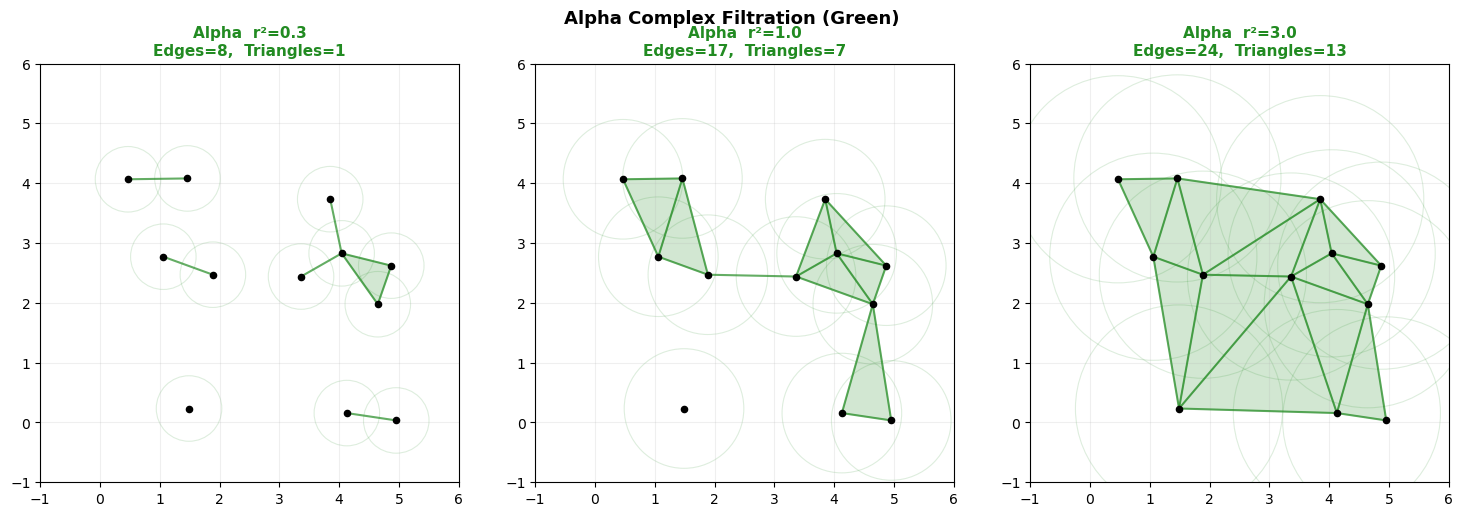


Note: Alpha complex only includes Delaunay-compatible simplices.
It uses far fewer simplices than Rips while having the same homotopy type as Čech.


In [28]:
# ── Section 3.3: Alpha Complex with GUDHI ─────────────────────────────────────
np.random.seed(99)
pts_alpha = np.random.rand(12, 2) * 5   # random points in [0,5]^2

alpha_complex = gudhi.AlphaComplex(points=pts_alpha)
simplex_tree_alpha = alpha_complex.create_simplex_tree()

print("Alpha Complex — full filtration (squared radius parameter):")
print(f"  Dimension : {simplex_tree_alpha.dimension()}")
print(f"  Simplices : {simplex_tree_alpha.num_simplices()}")
print(f"  Vertices  : {simplex_tree_alpha.num_vertices()}\n")

# Print the first 20 simplices
fmt = '%s  ->  filtration value = %.4f'
for i, (s, f) in enumerate(simplex_tree_alpha.get_filtration()):
    if i < 20:
        print(fmt % (s, f))
print("...")

# ── Visualize three snapshots of the Alpha filtration ─────────────────────────
r_thresholds = [0.3, 1.0, 3.0]   # squared-radius thresholds

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, r2 in zip(axes, r_thresholds):
    # Create a fresh copy and prune
    st_snap = alpha_complex.create_simplex_tree()
    st_snap.prune_above_filtration(r2)

    for simplex, _ in st_snap.get_filtration():
        if len(simplex) == 3:
            tri = pts_alpha[simplex, :]
            ax.fill(tri[:, 0], tri[:, 1], color='forestgreen', alpha=0.2)
        elif len(simplex) == 2:
            e = pts_alpha[simplex, :]
            ax.plot(e[:, 0], e[:, 1], color='forestgreen', linewidth=1.5, alpha=0.7)

    # Show balls of radius sqrt(r2)
    for pt in pts_alpha:
        c = mpatches.Circle(pt, radius=np.sqrt(r2), fc='none',
                            ec='forestgreen', alpha=0.15, linewidth=0.8)
        ax.add_patch(c)

    ax.scatter(pts_alpha[:, 0], pts_alpha[:, 1], s=20, c='k', zorder=5)
    n1 = sum(1 for s, _ in st_snap.get_filtration() if len(s) == 2)
    n2 = sum(1 for s, _ in st_snap.get_filtration() if len(s) == 3)
    ax.set_title(f'Alpha  r²={r2}\nEdges={n1},  Triangles={n2}',
                 fontsize=11, fontweight='bold', color='forestgreen')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-1, 6); ax.set_ylim(-1, 6)

plt.suptitle('Alpha Complex Filtration (Green)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: Alpha complex only includes Delaunay-compatible simplices.")
print("It uses far fewer simplices than Rips while having the same homotopy type as Čech.")

---

## 4. Comparing the Three Complexes

Now that we have explored each construction individually, let's put them **side-by-side on the same point cloud** at three increasing scale values.

We will use a small hexagonal arrangement of 6 points so every simplex is easy to follow. For each (complex, scale) pair, the plot shows:

- **Filled triangles**: 2-simplices
- **Edges**: 1-simplices  
- **Light circles**: the region of influence of each vertex (radius $r$ for Rips, $r/2$ for Čech)

Pay attention to which simplices appear at each scale and how the three constructions differ.

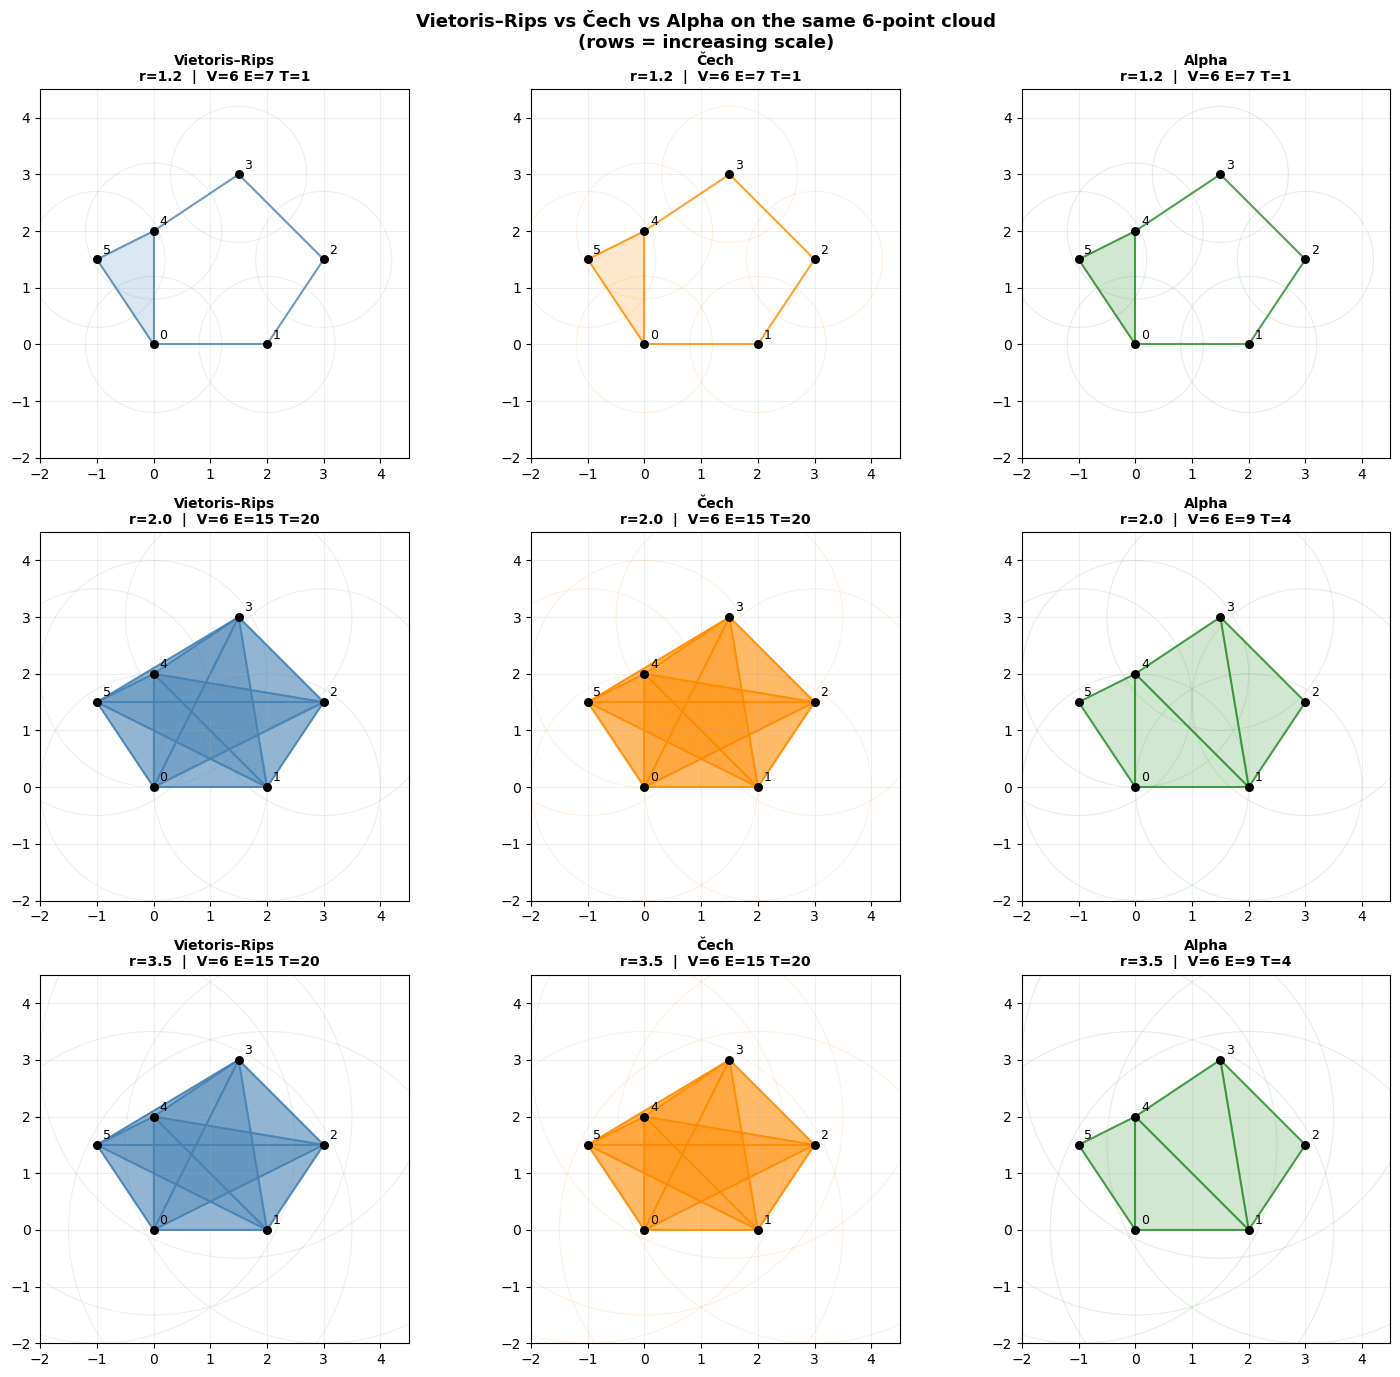

Key observation: at the same scale r, Čech ⊆ Rips (Čech is more conservative).
Alpha is a subcomplex of Čech and is always a subset of the Delaunay triangulation.


In [33]:
# ── Section 4: Compare all three complexes on the same small dataset ────────────
X_small = np.array([[0, 0],[2, 0],[3, 1.5],[1.5, 3],[0, 2],[-1, 1.5]], dtype=float)
R_vals = [1.2, 2.0, 3.5]

# Helper: wrap build_cech_filtration result into a gudhi.SimplexTree
def cech_simplex_tree(points, max_radius, max_dim=2):
    st = gudhi.SimplexTree()
    for sigma, r in build_cech_filtration(points, max_radius=max_radius, max_dim=max_dim):
        st.insert(sigma, filtration=r)
    return st

fig, axes = plt.subplots(3, 3, figsize=(15, 14))

complex_builders = {
    'Vietoris–Rips': lambda r: gudhi.RipsComplex(points=X_small, max_edge_length=2*r)
                                      .create_simplex_tree(max_dimension=2),
    'Čech':          lambda r: cech_simplex_tree(X_small, max_radius=r, max_dim=2),
    'Alpha':         lambda r: (lambda st: (st.prune_above_filtration(r**2), st)[1])(
                                    gudhi.AlphaComplex(points=X_small).create_simplex_tree()),
}
colors_map = {'Vietoris–Rips': 'steelblue', 'Čech': 'darkorange', 'Alpha': 'forestgreen'}

for col_idx, (name, builder) in enumerate(complex_builders.items()):
    for row_idx, r in enumerate(R_vals):
        ax = axes[row_idx, col_idx]
        st = builder(r)

        # Draw 2-simplices (triangles)
        for simplex, _ in st.get_filtration():
            if len(simplex) == 3:
                tri = X_small[simplex, :]
                ax.fill(tri[:, 0], tri[:, 1], color=colors_map[name], alpha=0.20)

        # Draw 1-simplices (edges)
        for simplex, _ in st.get_filtration():
            if len(simplex) == 2:
                e = X_small[simplex, :]
                ax.plot(e[:, 0], e[:, 1], color=colors_map[name], linewidth=1.5, alpha=0.8)

        # Draw 0-simplices (vertices) with balls
        for pt in X_small:
            circle = mpatches.Circle(pt, radius=r if name == 'Čech' else r,
                                     fc='none', ec=colors_map[name], alpha=0.12, linewidth=0.8)
            ax.add_patch(circle)
        ax.scatter(X_small[:, 0], X_small[:, 1], s=30, c='k', zorder=5)
        # Label points
        for i, (x, y) in enumerate(X_small):
            ax.annotate(str(i), (x + 0.1, y + 0.1), fontsize=9)

        n0 = sum(1 for s, _ in st.get_filtration() if len(s) == 1)
        n1 = sum(1 for s, _ in st.get_filtration() if len(s) == 2)
        n2 = sum(1 for s, _ in st.get_filtration() if len(s) == 3)
        ax.set_title(f'{name}\nr={r}  |  V={n0} E={n1} T={n2}', fontsize=10, fontweight='bold')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)
        lim = 4.5
        ax.set_xlim(-2, lim); ax.set_ylim(-2, lim)

plt.suptitle('Vietoris–Rips vs Čech vs Alpha on the same 6-point cloud\n(rows = increasing scale)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key observation: at the same scale r, Čech ⊆ Rips (Čech is more conservative).")
print("Alpha is a subcomplex of Čech and is always a subset of the Delaunay triangulation.")

---

## 5. Applied Example: Shape Inference from Noisy Data

A key motivation for filtrations is to **infer the shape of a point cloud** even in the presence of noise. We will use a noisy circle — a canonical example — where the underlying space is $S^1$ (one connected component, one loop).

The goal is to choose a scale $r$ at which the simplicial complex *captures* the circle's topology: one connected component and one 1-dimensional hole (loop).

We will:
1. Build all three complexes at the same scale and compare the number of simplices
2. Plot how simplex counts evolve as the scale grows

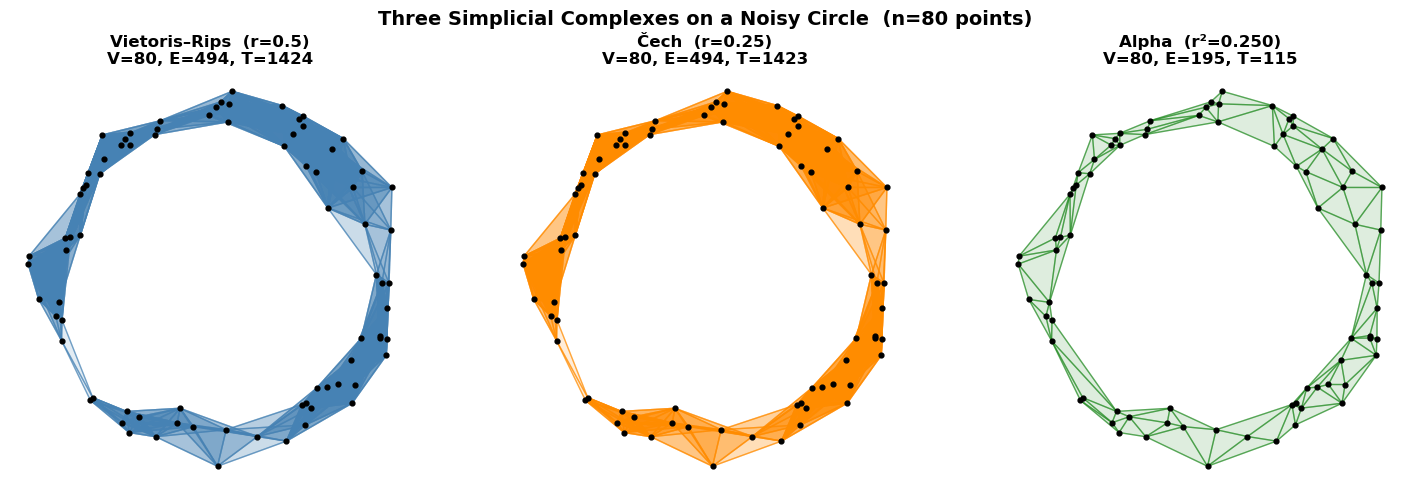

Rips:  1998 simplices
Čech:  1997 simplices
Alpha:  390 simplices

Note: Alpha is the sparsest — it only uses Delaunay-compatible simplices.


In [42]:
# ── Build all three complexes on the noisy circle and compare side-by-side ─────
np.random.seed(42)
circle_noisy = tadasets.dsphere(d=1, n=80, noise=0.08)   # noisy unit circle in R^2

SCALE_R = 0.25*2   # Rips max_edge_length
SCALE_C = 0.25  # Cech radius
SCALE_A = SCALE_R ** 2  # Alpha uses SQUARED radius

# Build simplex trees
st_rips = gudhi.RipsComplex(points=circle_noisy, max_edge_length=SCALE_R) \
               .create_simplex_tree(max_dimension=2)

# Čech: built manually via build_cech_filtration (gudhi.CechComplex requires
# optional CGAL bindings not compiled in this distribution)
st_cech = gudhi.SimplexTree()
for sigma, r in build_cech_filtration(circle_noisy, max_radius=SCALE_C, max_dim=2):
    st_cech.insert(sigma, filtration=r)

st_alpha = gudhi.AlphaComplex(points=circle_noisy).create_simplex_tree()
st_alpha.prune_above_filtration(SCALE_A)

def draw_complex(ax, points, simplex_tree, title, color='steelblue'):
    """Draw 0-, 1-, and 2-simplices from a simplex_tree onto ax."""
    for simplex, _ in simplex_tree.get_filtration():
        if len(simplex) == 3:
            tri = points[simplex, :]
            ax.fill(tri[:, 0], tri[:, 1], color=color, alpha=0.15)
        elif len(simplex) == 2:
            e = points[simplex, :]
            ax.plot(e[:, 0], e[:, 1], color=color, linewidth=1, alpha=0.7)
    ax.scatter(points[:, 0], points[:, 1], s=12, color='k', zorder=5)
    n0 = sum(1 for s, _ in simplex_tree.get_filtration() if len(s) == 1)
    n1 = sum(1 for s, _ in simplex_tree.get_filtration() if len(s) == 2)
    n2 = sum(1 for s, _ in simplex_tree.get_filtration() if len(s) == 3)
    ax.set_title(f'{title}\nV={n0}, E={n1}, T={n2}', fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
draw_complex(axes[0], circle_noisy, st_rips,  f'Vietoris–Rips  (r={SCALE_R})', color='steelblue')
draw_complex(axes[1], circle_noisy, st_cech,  f'Čech  (r={SCALE_C})',            color='darkorange')
draw_complex(axes[2], circle_noisy, st_alpha, f'Alpha  (r²={SCALE_A:.3f})',       color='forestgreen')

plt.suptitle('Three Simplicial Complexes on a Noisy Circle  (n=80 points)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Rips:  {st_rips.num_simplices():4d} simplices")
print(f"Čech:  {st_cech.num_simplices():4d} simplices")
print(f"Alpha: {st_alpha.num_simplices():4d} simplices")
print("\nNote: Alpha is the sparsest — it only uses Delaunay-compatible simplices.")

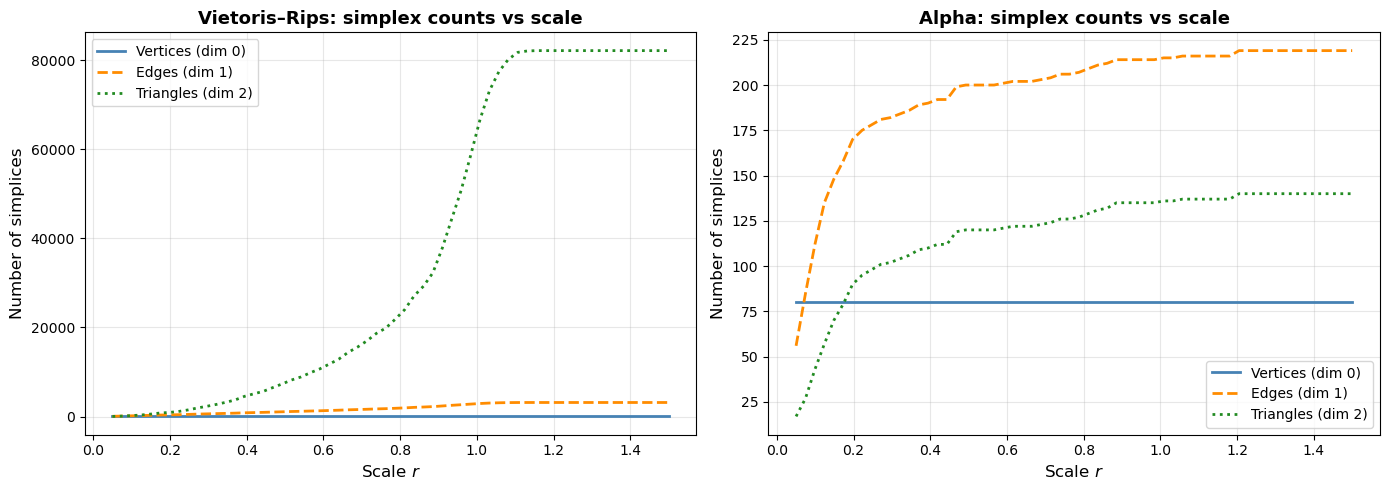

Observations:
- Rips connects all points much faster (more edges/triangles at smaller scale)
- Alpha stays sparse for longer because it respects the Delaunay neighbourhood
- The noisy circle topology (1-loop) is captured in the range where edges >> vertices


In [38]:
# ── Applied example: count simplices vs scale for the three complexes ──────────
scales = np.linspace(0.05, 1.5, 60)

rips_counts   = {'0-simplices': [], '1-simplices': [], '2-simplices': []}
alpha_counts  = {'0-simplices': [], '1-simplices': [], '2-simplices': []}

for r in scales:
    # Rips
    st_r = gudhi.RipsComplex(points=circle_noisy, max_edge_length=2*r).create_simplex_tree(max_dimension=2)
    for key, d in zip(rips_counts.keys(), [0, 1, 2]):
        rips_counts[key].append(sum(1 for s, _ in st_r.get_filtration() if len(s) == d + 1))
    # Alpha (parameter is squared radius)
    st_a = gudhi.AlphaComplex(points=circle_noisy).create_simplex_tree()
    st_a.prune_above_filtration(r ** 2)
    for key, d in zip(alpha_counts.keys(), [0, 1, 2]):
        alpha_counts[key].append(sum(1 for s, _ in st_a.get_filtration() if len(s) == d + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

linestyles = ['-', '--', ':']
colors = ['steelblue', 'darkorange', 'forestgreen']
labels = ['Vertices (dim 0)', 'Edges (dim 1)', 'Triangles (dim 2)']

for ax, counts, title in zip(axes, [rips_counts, alpha_counts],
                             ['Vietoris–Rips', 'Alpha']):
    for (key, vals), ls, c, lbl in zip(counts.items(), linestyles, colors, labels):
        ax.plot(scales, vals, linestyle=ls, color=c, linewidth=2, label=lbl)
    ax.set_title(f'{title}: simplex counts vs scale', fontsize=13, fontweight='bold')
    ax.set_xlabel('Scale $r$', fontsize=12)
    ax.set_ylabel('Number of simplices', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print("- Rips connects all points much faster (more edges/triangles at smaller scale)")
print("- Alpha stays sparse for longer because it respects the Delaunay neighbourhood")
print("- The noisy circle topology (1-loop) is captured in the range where edges >> vertices")

---

## Summary and Key Takeaways

### What We Learned

1. **Simplicial Complexes** are combinatorial objects built from vertices (0-simplices), edges (1-simplices), triangles (2-simplices), etc. They encode connectivity and topological relationships in data.

2. **Filtrations** are nested sequences $\emptyset = K_0 \subseteq K_1 \subseteq \cdots \subseteq K_m = K$ indexed by a real parameter (e.g., scale $r$). Each complex in the sequence captures more of the data's structure at coarser resolution.

3. **Vietoris–Rips Complex** $\mathcal{R}(r)$:
   - Connects any subset of points whose **pairwise distances** are all $\leq r$
   - Easily computed from a distance matrix
   - Used by `gudhi.RipsComplex`

4. **Čech Complex** $\mathcal{C}(r)$:
   - Includes a simplex if the **balls of radius $r/2$** around its vertices have a common intersection
   - By the Nerve Theorem, $\mathcal{C}(r)$ is homotopy equivalent to the union of balls
   - More topologically faithful but computationally demanding
   - Used by `gudhi.CechComplex`

5. **Alpha Complex** $\mathcal{A}(r)$:
   - A subcomplex of the **Delaunay triangulation**, restricted to scale $r$
   - Same homotopy type as the Čech complex but with far fewer simplices
   - Efficient in low dimensions (typically ≤ 3)
   - Used by `gudhi.AlphaComplex`

### Relationship Between the Three Complexes

For any scale $r$:
$$\mathcal{A}(r) \subseteq \mathcal{C}(r) \subseteq \mathcal{R}(r) \subseteq \mathcal{C}(\sqrt{2}\, r)$$

### Practical Guidance

| Complex | Pro | Con |
|---------|-----|-----|
| Vietoris–Rips | Simple from distances; fast | Over-connects in high dim |
| Čech | Topologically exact (Nerve Thm) | Slow; exponentially many checks |
| Alpha | Efficient; sparse in 2D/3D | Requires Delaunay; bad in high dim |

### Further Reading

- Edelsbrunner & Harer (2010). *Computational Topology: An Introduction*
- Gudhi documentation: https://gudhi.inria.fr/doc/latest/
- Zomorodian (2005). *Topology for Computing*

---

**Congratulations!** You now understand the three main constructions for building simplicial complexes from data and can use `gudhi` to filter them and visualize their evolution.

---

## Exercises

Try these exercises to deepen your understanding:

### Exercise 1: Parameter Sensitivity
For the noisy circle dataset, systematically vary the `max_edge_length` parameter of the Vietoris–Rips complex from 0.1 to 2.5 in steps of 0.1. Plot the number of 0-, 1-, and 2-simplices as a function of the parameter. At what threshold do all points become connected?

### Exercise 2: Different Shapes
Use `tadasets` to generate point clouds from different shapes (sphere `dsphere(d=2)`, torus `dtorus`, etc.) and build all three types of complexes for an appropriate scale. Describe which complex seems to capture the topology best.

```python
# Hint: generate a noisy torus
import tadasets
np.random.seed(42)
torus_data = tadasets.torus(n=200, c=2, a=1, noise=0.05)
```

### Exercise 3: Filtration Tree
For a small dataset of your choice (5–8 points in 2D), manually print the full filtration from `gudhi` and draw it by hand: sketch which simplices appear at each scale value. Count the number of connected components and loops at three different scale values.

### Exercise 4: Alpha vs Rips on Dense Data
Generate 300 points uniformly on a circle. Observe that the Alpha complex uses far fewer simplices than the Rips complex for the same scale. Quantify the ratio of number of simplices between the two. Why is the Alpha complex more efficient?

### Exercise 5: Čech vs Rips Relationship
The Čech complex $\mathcal{C}(r)$ and Vietoris–Rips complex $\mathcal{R}(r)$ are related by the interleaving:
$$\mathcal{C}(r) \subseteq \mathcal{R}(r) \subseteq \mathcal{C}(\sqrt{2}\, r)$$
Verify this relationship numerically on a small point cloud: for a fixed $r$, count how many simplices are in each complex and confirm the containment.

---

**Good luck with your explorations!**

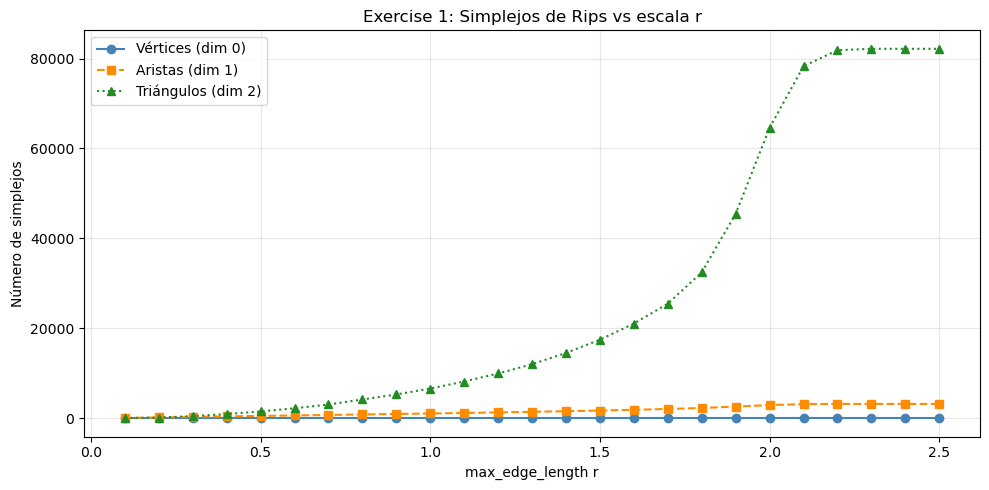

In [43]:
# ══════════════════════════════════════════════════════════════════════
# EJERCICIO 1: Sensibilidad al parámetro — Rips en círculo ruidoso
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import gudhi
import tadasets
import matplotlib.pyplot as plt

np.random.seed(42)
circle_noisy = tadasets.dsphere(d=1, n=80, noise=0.08)

# Barremos 25 valores de r entre 0.1 y 2.5
scales = np.arange(0.1, 2.6, 0.1)

counts = {'0-simplices': [], '1-simplices': [], '2-simplices': []}

for r in scales:
    st = gudhi.RipsComplex(points=circle_noisy, max_edge_length=r) \
              .create_simplex_tree(max_dimension=2)
    
    # Contamos cuántos simplejos de cada dimensión hay
    counts['0-simplices'].append(sum(1 for s,_ in st.get_filtration() if len(s)==1))
    counts['1-simplices'].append(sum(1 for s,_ in st.get_filtration() if len(s)==2))
    counts['2-simplices'].append(sum(1 for s,_ in st.get_filtration() if len(s)==3))

plt.figure(figsize=(10,5))
plt.plot(scales, counts['0-simplices'], 'o-', label='Vértices (dim 0)', color='steelblue')
plt.plot(scales, counts['1-simplices'], 's--', label='Aristas (dim 1)',  color='darkorange')
plt.plot(scales, counts['2-simplices'], '^:',  label='Triángulos (dim 2)',color='forestgreen')
plt.xlabel('max_edge_length r')
plt.ylabel('Número de simplejos')
plt.title('Exercise 1: Simplejos de Rips vs escala r')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ¿A qué r todos los puntos están conectados?
# = cuando los vértices bajan a 1 componente conexa
# Calculamos β₀ para cada r
bettis = []
for r in scales:
    st = gudhi.RipsComplex(points=circle_noisy, max_edge_length=r) \
              .create_simplex_tree(max_dimension=2)
    st.compute_persistence()
    b0 = sum(1 for d,_ in st.persistence() if d==0)
    bettis.append(b0)

# Primer r donde β₀ = 1 (un solo componente)
for r, b in zip(scales, bettis):
    if b == 1:
        print(f"Todos conectados a r = {r:.1f}  (β₀ = 1)")
        break

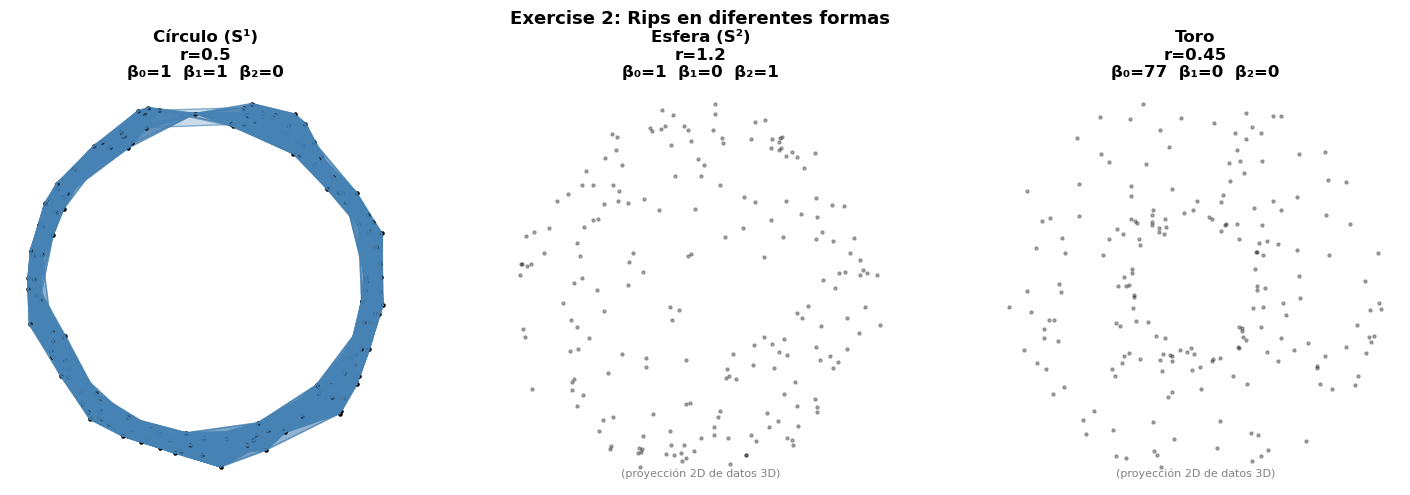

In [53]:
# ══════════════════════════════════════════════════════════════════════
# EJERCICIO 2: Diferentes formas — esfera, toro, círculo
# ══════════════════════════════════════════════════════════════════════
np.random.seed(42)
circle = tadasets.dsphere(d=1, n=150, noise=0.05)
sphere = tadasets.dsphere(d=2, n=200, noise=0.05)
torus  = tadasets.torus(n=200, c=2, a=1, noise=0.05)
# ✅ Radio más grande para datos 3D
r_circle = 0.5   # círculo en R² — este ya funciona
r_3d     = 1.2   # esfera y toro en R³ necesitan más

shapes = {
    'Círculo (S¹)': (circle, r_circle),
    'Esfera (S²)':  (sphere, r_3d),
    'Toro':         (torus,  0.45),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, (data, r)) in zip(axes, shapes.items()):
    
    st = gudhi.RipsComplex(points=data, max_edge_length=r) \
              .create_simplex_tree(max_dimension=3)
    st.compute_persistence()
    
    betti = st.betti_numbers()
    b0 = betti[0] if len(betti) > 0 else 0
    b1 = betti[1] if len(betti) > 1 else 0
    b2 = betti[2] if len(betti) > 2 else 0
    
    if data.shape[1] == 2:
        for simplex, _ in st.get_filtration():
            if len(simplex)==3:
                tri = data[simplex]
                ax.fill(tri[:,0], tri[:,1], alpha=0.1, color='steelblue')
            elif len(simplex)==2:
                e = data[simplex]
                ax.plot(e[:,0], e[:,1], 'steelblue', lw=0.8, alpha=0.5)
        ax.scatter(data[:,0], data[:,1], s=5, c='k')
    else:
        ax.scatter(data[:,0], data[:,1], s=5, c='k', alpha=0.3)
        ax.text(0.5, 0.02, '(proyección 2D de datos 3D)',
                transform=ax.transAxes, ha='center', fontsize=8, color='gray')
    
    ax.set_title(f'{name}\nr={r}\nβ₀={b0}  β₁={b1}  β₂={b2}', fontweight='bold')
    ax.set_aspect('equal'); ax.axis('off')

plt.suptitle('Exercise 2: Rips en diferentes formas', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Filtración completa (símplex → r en que aparece):
Símplex                     r
------------------------------
[0]                    0.0000  (vértice)
[1]                    0.0000  (vértice)
[2]                    0.0000  (vértice)
[3]                    0.0000  (vértice)
[4]                    0.0000  (vértice)
[5]                    0.0000  (vértice)
[4, 5]                 1.1180  (arista)
[1, 2]                 1.8028  (arista)
[3, 4]                 1.8028  (arista)
[0, 5]                 1.8028  (arista)
[0, 1]                 2.0000  (arista)
[0, 4]                 2.0000  (arista)
[0, 4, 5]              2.0000  (triángulo)
[2, 3]                 2.1213  (arista)
[1, 4]                 2.8284  (arista)
[0, 1, 4]              2.8284  (triángulo)
[3, 5]                 2.9155  (arista)
[3, 4, 5]              2.9155  (triángulo)
[1, 3]                 3.0414  (arista)
[1, 2, 3]              3.0414  (triángulo)
[2, 4]                 3.0414  (arista)
[1, 2, 4]              3.0414  

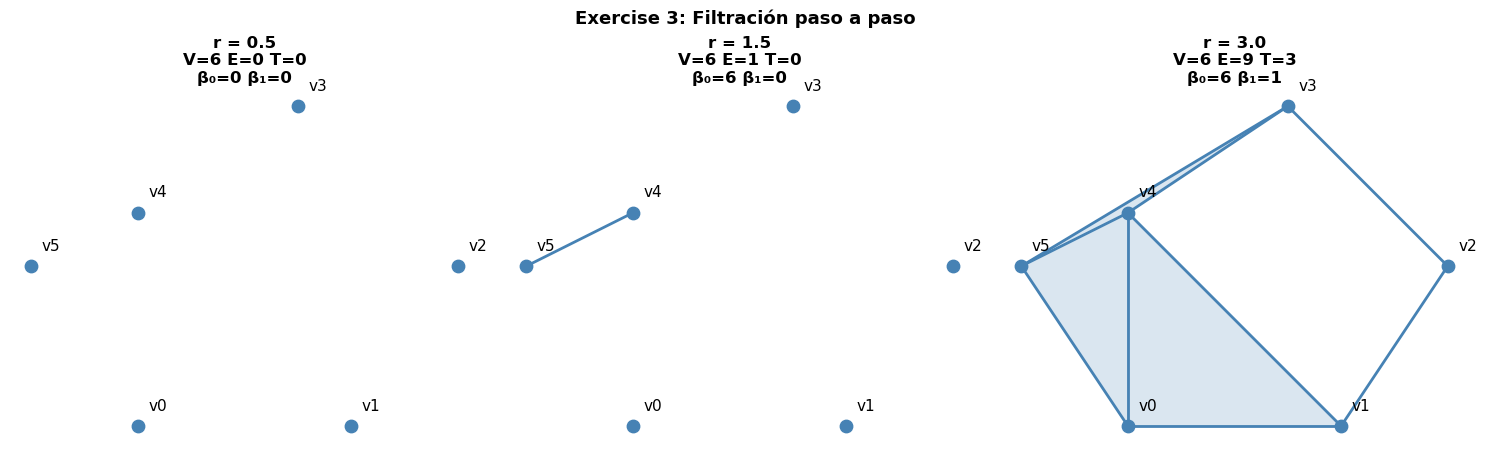

In [46]:
# ══════════════════════════════════════════════════════════════════════
# EJERCICIO 3: Filtración manual — imprimir y dibujar
# ══════════════════════════════════════════════════════════════════════

# Dataset pequeño: 6 puntos en 2D
pts = np.array([[0,0],[2,0],[3,1.5],[1.5,3],[0,2],[-1,1.5]], dtype=float)

# Construimos Rips con radio grande para ver la filtración completa
st = gudhi.RipsComplex(points=pts, max_edge_length=5.0) \
          .create_simplex_tree(max_dimension=2)

# Imprimimos todos los simplejos ordenados por valor de filtración
print("Filtración completa (símplex → r en que aparece):")
print(f"{'Símplex':<20} {'r':>8}")
print("-" * 30)
for simplex, filt_val in st.get_filtration():
    dim = len(simplex) - 1
    tipo = ['vértice','arista','triángulo'][dim]
    print(f"{str(simplex):<20} {filt_val:>8.4f}  ({tipo})")

# Dibujamos 3 snapshots a diferentes r
r_vals = [0.5, 1.5, 3.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, r in zip(axes, r_vals):
    snap = gudhi.RipsComplex(points=pts, max_edge_length=r) \
                .create_simplex_tree(max_dimension=2)
    snap.compute_persistence()
    
    b0 = sum(1 for d,_ in snap.persistence() if d==0)
    b1 = sum(1 for d,_ in snap.persistence() if d==1)
    
    for simplex, _ in snap.get_filtration():
        if len(simplex)==3:
            tri = pts[simplex]
            ax.fill(tri[:,0], tri[:,1], alpha=0.2, color='steelblue')
        elif len(simplex)==2:
            e = pts[simplex]
            ax.plot(e[:,0], e[:,1], 'steelblue', lw=2)
    
    ax.scatter(pts[:,0], pts[:,1], s=80, c='steelblue', zorder=5)
    for i,(x,y) in enumerate(pts):
        ax.annotate(f'v{i}', (x+0.1, y+0.15), fontsize=11)
    
    n0 = sum(1 for s,_ in snap.get_filtration() if len(s)==1)
    n1 = sum(1 for s,_ in snap.get_filtration() if len(s)==2)
    n2 = sum(1 for s,_ in snap.get_filtration() if len(s)==3)
    ax.set_title(f'r = {r}\nV={n0} E={n1} T={n2}\nβ₀={b0} β₁={b1}', fontweight='bold')
    ax.set_aspect('equal'); ax.axis('off')

plt.suptitle('Exercise 3: Filtración paso a paso', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Rips:  34635 simplejos
Alpha:  1658 simplejos
Ratio: 20.9x  — Rips tiene 20.9 veces más simplejos que Alpha

¿Por qué Alpha es más eficiente?
→ Solo conecta vecinos de Delaunay (vecinos naturales)
→ Descarta conexiones 'largas' que Rips incluiría
→ Para un círculo con 300 pts, Rips conecta casi todo
  con cada punto; Alpha solo conecta los vecinos inmediatos


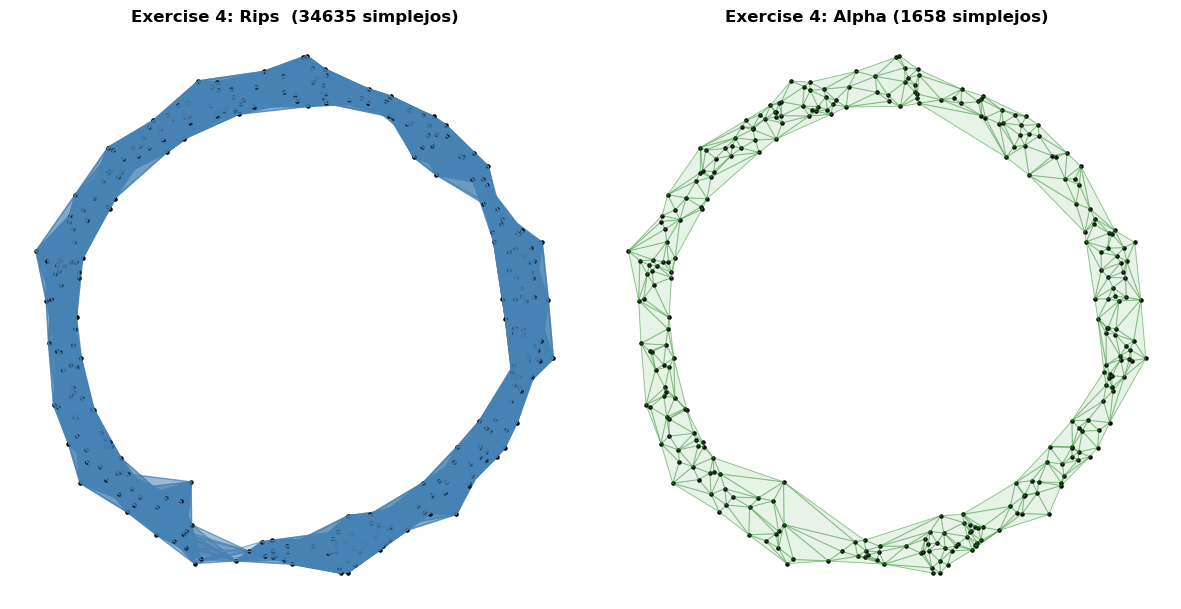

In [47]:
# ══════════════════════════════════════════════════════════════════════
# EJERCICIO 4: Alpha vs Rips en datos densos
# ══════════════════════════════════════════════════════════════════════

np.random.seed(42)
dense_circle = tadasets.dsphere(d=1, n=300, noise=0.05)

r = 0.3
r_sq = r**2

# Rips
st_rips = gudhi.RipsComplex(points=dense_circle, max_edge_length=r) \
               .create_simplex_tree(max_dimension=2)

# Alpha (recordar: prune con r²)
st_alpha = gudhi.AlphaComplex(points=dense_circle).create_simplex_tree()
st_alpha.prune_above_filtration(r_sq)

n_rips  = st_rips.num_simplices()
n_alpha = st_alpha.num_simplices()
ratio   = n_rips / n_alpha

print(f"Rips:  {n_rips:5d} simplejos")
print(f"Alpha: {n_alpha:5d} simplejos")
print(f"Ratio: {ratio:.1f}x  — Rips tiene {ratio:.1f} veces más simplejos que Alpha")
print()
print("¿Por qué Alpha es más eficiente?")
print("→ Solo conecta vecinos de Delaunay (vecinos naturales)")
print("→ Descarta conexiones 'largas' que Rips incluiría")
print("→ Para un círculo con 300 pts, Rips conecta casi todo")
print("  con cada punto; Alpha solo conecta los vecinos inmediatos")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (st, name, col) in zip(axes, [
    (st_rips,  f'Rips  ({n_rips} simplejos)',  'steelblue'),
    (st_alpha, f'Alpha ({n_alpha} simplejos)', 'forestgreen')
]):
    for simplex, _ in st.get_filtration():
        if len(simplex)==3:
            tri = dense_circle[simplex]
            ax.fill(tri[:,0], tri[:,1], alpha=0.1, color=col)
        elif len(simplex)==2:
            e = dense_circle[simplex]
            ax.plot(e[:,0], e[:,1], color=col, lw=0.5, alpha=0.5)
    ax.scatter(dense_circle[:,0], dense_circle[:,1], s=5, c='k')
    ax.set_title(f'Exercise 4: {name}', fontweight='bold')
    ax.set_aspect('equal'); ax.axis('off')

plt.tight_layout(); plt.show()

In [48]:
# ══════════════════════════════════════════════════════════════════════
# EJERCICIO 5: Verificar C(r) ⊆ R(r) ⊆ C(√2 · r)
# ══════════════════════════════════════════════════════════════════════

# Dataset pequeño para poder verificar manualmente
np.random.seed(0)
pts_small = np.random.rand(8, 2) * 3  # 8 puntos en [0,3]²

r = 1.0  # radio fijo

# ── Construimos los 3 complejos ──────────────────
# C(r): Čech con radio r
def build_cech(points, max_radius, max_dim=2):
    st = gudhi.SimplexTree()
    for sigma, rv in build_cech_filtration(points, max_radius=max_radius, max_dim=max_dim):
        st.insert(sigma, filtration=rv)
    return st

cech_r      = build_cech(pts_small, max_radius=r)           # C(r)
rips_r      = gudhi.RipsComplex(points=pts_small,            # R(r)
                  max_edge_length=2*r).create_simplex_tree(max_dimension=2)
cech_sqrt2r = build_cech(pts_small, max_radius=np.sqrt(2)*r) # C(√2·r)

# ── Extraemos los simplejos de cada uno ──────────
def get_simplices(st):
    return set(tuple(s) for s,_ in st.get_filtration())

S_cech_r      = get_simplices(cech_r)
S_rips_r      = get_simplices(rips_r)
S_cech_sqrt2r = get_simplices(cech_sqrt2r)

# ── Verificamos las contenciones ─────────────────
cech_in_rips  = S_cech_r.issubset(S_rips_r)
rips_in_cech2 = S_rips_r.issubset(S_cech_sqrt2r)

print(f"r = {r}")
print(f"√2·r = {np.sqrt(2)*r:.4f}")
print()
print(f"|C(r)|      = {len(S_cech_r):4d} simplejos")
print(f"|R(r)|      = {len(S_rips_r):4d} simplejos")  
print(f"|C(√2·r)|   = {len(S_cech_sqrt2r):4d} simplejos")
print()
print(f"C(r) ⊆ R(r)      → {'✅ VERDADERO' if cech_in_rips  else '❌ FALSO'}")
print(f"R(r) ⊆ C(√2·r)   → {'✅ VERDADERO' if rips_in_cech2 else '❌ FALSO'}")
print()
print(f"Conclusión: C(r) ⊆ R(r) ⊆ C(√2·r)  →  {'✅ VERIFICADO' if cech_in_rips and rips_in_cech2 else '❌ NO VERIFICADO'}")

r = 1.0
√2·r = 1.4142

|C(r)|      =   54 simplejos
|R(r)|      =   54 simplejos
|C(√2·r)|   =   84 simplejos

C(r) ⊆ R(r)      → ✅ VERDADERO
R(r) ⊆ C(√2·r)   → ✅ VERDADERO

Conclusión: C(r) ⊆ R(r) ⊆ C(√2·r)  →  ✅ VERIFICADO
